# Hybrid RF + CNN — Summary Statistics Meet Temporal Convolutions

## Research Question

Can a **temporal CNN** add signal on top of the **per-star summary statistics** that already give the Random Forest its ROC-AUC of **0.7994**?

- **Random Forest** (16 per-star physical summary stats): ROC-AUC **0.7994**, PR-AUC **0.4658**, Best F1 **0.5221**. Learns from aggregate numbers per star (scatter, activity level, correlations) — the *big picture*.
- **Transformer** (raw sequences + sinusoidal positional encoding): ROC-AUC **0.6793**. Global attention overfits a ~2000-star dataset.
- **1D CNN** (raw sequences + positional encoding): ROC-AUC **0.6490**, PR-AUC **0.3049**, Best F1 **0.3887**. Local inductive bias still has to learn everything from scratch.
- **Hybrid RF+CNN** (this notebook): a single neural network with **two parallel branches** — one consumes the 16 summary statistics, the other consumes the raw observation sequence — merged before a shared classifier head.

## The Hypothesis

> **The CNN can only help, never hurt.** Worst case, the temporal branch learns nothing useful and the summary-stats branch carries the model — the hybrid regresses to RF performance. If any local temporal structure is informative beyond what the summary statistics capture, the hybrid *beats* the RF.

This is the most informative single experiment in the project: a clean test of whether temporal structure carries signal that per-star aggregates throw away, while giving the model the aggregates for free.

## Architecture

```
                         ┌─────────────────────────────────────────────┐
   16 summary stats ─────►│ Branch 1 (summary)                         │── 32-dim ──┐
   (rv_std, …, corr)      │ Linear(16→32) → GELU → Dropout →            │            │
                          │ Linear(32→32) → GELU → Dropout              │            │
                          └─────────────────────────────────────────────┘            │
                                                                                     ▼
   raw sequence  ─────────┐                                                     ┌──────────┐
   (T, 4)                │ Branch 2 (temporal CNN)                              │  Concat  │── 96-dim
   [rv_centered,         │ Conv1d(4→64,k=5) → BN → GELU → Drop(0.3)            │          │
    rv_err,              │ Conv1d(64→64,k=5) → BN → GELU → Drop(0.3)            │          │
    RHKp, Halpha]        │ Conv1d(64→32,k=3) → BN → GELU → Drop(0.3)           │          │
   (no positional enc)   │ masked global avg + max pool → 64-dim              └────┬─────┘
                         └─────────────────────────────────────────────┘            ▼
                                                                            Linear(96→32) → GELU → Dropout
                                                                                       ▼
                                                                            Linear(32→1) → logit
```

- **Branch 1** (summary stats, 16→32→32, ~1.5K params): same 16 physical features the RF uses, fed into two linear layers with GELU + Dropout. This branch *learns* to use the statistics.
- **Branch 2** (temporal CNN, ~28K params): the raw 4-channel observation sequence (`rv_centered`, `rv_err`, `RHKp`, `Halpha`) — **no positional encoding**, matching the stripped CNN. Three conv blocks (k=5, 5, 3) each with 'same' padding + BatchNorm + GELU + Dropout(0.3), then masked global avg+max pooling → 64-dim.
- **Merge**: concatenate → 96-dim → `Linear(96→32)` → GELU → Dropout → `Linear(32→1)`.
- **Total parameters**: ~80K–120K — small enough to resist overfitting the ~2000-star dataset, large enough to learn rich local detectors.

## Why this design

- **Branch 2 is the stripped CNN** (4 channels, no positional encoding) — if temporal structure carries planet signal, this branch finds it. If it doesn't, the branch's contribution gets driven toward zero by the classifier head and the model falls back on Branch 1 alone (i.e., RF performance).
- **Branch 1 uses the same 16 physical summary statistics** as the ablated RF, so the hybrid is directly comparable to the best baseline.
- **Merging before the classifier** (not late score averaging) lets the head learn *interactions* between big-picture statistics and local temporal features — something neither the RF nor the CNN can do alone.


## 1. Load Data, Compute Summary Stats & Build Raw Sequences

For each star we produce **two views** of the same observations:

1. **16 physical summary statistics** — computed with the self-contained `compute_star_features` function (same formulas as `baseline.ipynb`): RV scatter (`rv_std`, `rv_range`, `rv_mean_abs_dev`, `rv_skew`, `rv_kurtosis`), RV error stats (`rv_err_mean`, `rv_err_std`), activity indicator stats (`rhkp_std/range/mean`, `halpha_std/range/mean`), and RV↔activity correlations (`rv_rhkp_corr`, `rv_halpha_corr`, `rhkp_halpha_corr`).
2. **4-channel raw observation sequence** `[rv_centered, rv_err, RHKp, Halpha]` sorted by `bjd` — the input to Branch 2 (no positional encoding).

Both views share the same per-star train/val/test split, so the same star's statistics and its raw sequence always land in the same partition.


In [1]:
import pandas as pd
import numpy as np

observations = pd.DataFrame(pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'))

print(f"Total observations: {len(observations)}")
print(f"Stars: {observations['star_name'].nunique()}")
print(f"Columns: {list(observations.columns)}")
print(f"Positive stars: {observations[observations['has_exoplanets']==1]['star_name'].nunique()}")
print(f"Negative stars: {observations[observations['has_exoplanets']==0]['star_name'].nunique()}")

# ── The 16 physical summary statistics (self-contained, same formulas as baseline.ipynb) ──
SUMMARY_FEATURES = [
    'rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis',
    'rv_err_mean', 'rv_err_std',
    'rhkp_std', 'rhkp_range', 'rhkp_mean',
    'halpha_std', 'halpha_range', 'halpha_mean',
    'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr',
]

def compute_star_features(group):
    """Compute the 16 physical summary statistics for one star.

    Self-contained: takes a per-star observation DataFrame and returns a Series
    of the 16 features. Identical formulas to baseline.ipynb's ablation set.
    """
    features = {}
    # -- RV statistics --
    features['rv_std']           = group['rv_centered'].std()
    features['rv_range']         = group['rv_centered'].max() - group['rv_centered'].min()
    features['rv_mean_abs_dev']  = (group['rv_centered'] - group['rv_centered'].median()).abs().mean()
    features['rv_skew']          = group['rv_centered'].skew()
    features['rv_kurtosis']      = group['rv_centered'].kurtosis()
    # -- RV error statistics --
    features['rv_err_mean']      = group['rv_err'].mean()
    features['rv_err_std']       = group['rv_err'].std()
    # -- Activity indicator statistics --
    features['rhkp_std']         = group['RHKp'].std()
    features['rhkp_range']       = group['RHKp'].max() - group['RHKp'].min()
    features['rhkp_mean']        = group['RHKp'].mean()
    features['halpha_std']       = group['Halpha'].std()
    features['halpha_range']     = group['Halpha'].max() - group['Halpha'].min()
    features['halpha_mean']      = group['Halpha'].mean()
    # -- RV-activity correlations --
    features['rv_rhkp_corr']      = group['rv_centered'].corr(group['RHKp'])
    features['rv_halpha_corr']    = group['rv_centered'].corr(group['Halpha'])
    features['rhkp_halpha_corr']  = group['RHKp'].corr(group['Halpha'])
    return pd.Series(features)

# ── 4-channel raw sequence channels (Branch 2 input, NO positional encoding) ──
SEQ_CHANNELS = ['rv_centered', 'rv_err', 'RHKp', 'Halpha']

# Build per-star (summary, sequence, label) tuples, sorted by bjd.
stars = list(observations['star_name'].unique())
stars_summary = []   # list of (16,) np.float32
stars_seq     = []   # list of (T_i, 4) np.float32
stars_label   = []   # 0/1

for star in stars:
    g = observations[observations['star_name'] == star].sort_values('bjd')
    if len(g) == 0:
        continue
    feats = compute_star_features(g).fillna(0.0)
    stars_summary.append(feats[SUMMARY_FEATURES].values.astype(np.float32))
    stars_seq.append(g[SEQ_CHANNELS].values.astype(np.float32))
    stars_label.append(int(g['has_exoplanets'].iloc[0]))

stars_summary = np.array(stars_summary, dtype=np.float32)   # (N, 16)
stars_label   = np.array(stars_label,   dtype=np.int64)     # (N,)

assert stars_summary.shape[1] == 16, f"expected 16 summary features, got {stars_summary.shape[1]}"
assert len(stars_seq) == len(stars_summary) == len(stars_label)

print(f"\nBuilt {len(stars_summary)} per-star examples.")
print(f"Summary feature matrix: {stars_summary.shape}")
print(f"Positive: {stars_label.sum()}, Negative: {(1-stars_label).sum()}")
print(f"Sequence lengths: min={min(len(s) for s in stars_seq)}, "
      f"max={max(len(s) for s in stars_seq)}, "
      f"median={int(np.median([len(s) for s in stars_seq]))}")
print(f"Sequence channels: {SEQ_CHANNELS}  (no positional encoding)")


Total observations: 235567
Stars: 2187
Columns: ['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time', 'RHKp', 'Halpha', 'has_exoplanets', 'rv_centered']
Positive stars: 413
Negative stars: 1774


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Built 2187 per-star examples.
Summary feature matrix: (2187, 16)
Positive: 413, Negative: 1774
Sequence lengths: min=18, max=11469, median=41
Sequence channels: ['rv_centered', 'rv_err', 'RHKp', 'Halpha']  (no positional encoding)


## 2. Stratified 60/20/20 Split + Standardization

- **Split by star** (never by observation) — prevents an individual star's epochs from leaking across partitions.
- **60/20/20** via two `train_test_split` calls with `random_state=42`: first call `stratify=y` (the full label vector), second call `stratify=y_temp` (the temp-set labels). The second split does **not** use `stratify=y` — that would be a dimension mismatch.
- **Standardize BOTH views using training stats only**:
  - Summary statistics: per-feature mean/std over the training split.
  - Raw sequences: per-channel mean/std over all *training observations* pooled across training stars.
- **Truncate sequences to `max_seq_len=100`** observations (longer cadence-targeted stars are uncommon; bounds memory and lets较短 sequences keep full resolution).


In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import random

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed = 42
seed_everything(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MAX_SEQ_LEN = 100

# ── Stratified 60/20/20 split by star ──
# stage 1: 60 / 40 with stratify=y (full-label vector)
idx_all = np.arange(len(stars_label))
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, stars_label, test_size=0.4, random_state=seed, stratify=stars_label,
)
# stage 2: 20 / 20 from the temp set with stratify=y_temp (NOT stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp,
)

# Slice the two views into the three partitions.
train_summary = stars_summary[idx_train]
val_summary   = stars_summary[idx_val]
test_summary  = stars_summary[idx_test]

train_seq = [stars_seq[i] for i in idx_train]
val_seq   = [stars_seq[i] for i in idx_val]
test_seq  = [stars_seq[i] for i in idx_test]

y_train = stars_label[idx_train]
y_val   = stars_label[idx_val]
y_test  = stars_label[idx_test]

# ── Standardize SUMMARY STATS using training stats only ──
summ_mean = train_summary.mean(axis=0)
summ_std  = np.clip(train_summary.std(axis=0), 1e-8, None)
train_summary = (train_summary - summ_mean) / summ_std
val_summary   = (val_summary   - summ_mean) / summ_std
test_summary  = (test_summary  - summ_mean) / summ_std

# ── Standardize RAW SEQUENCES using training-observation stats only ──
train_all_obs = np.concatenate(train_seq, axis=0)   # (n_train_obs, 4)
seq_mean = train_all_obs.mean(axis=0)
seq_std  = np.clip(train_all_obs.std(axis=0), 1e-8, None)

def standardize_seq(seqlist):
    return [(s - seq_mean) / seq_std for s in seqlist]

train_seq = standardize_seq(train_seq)
val_seq   = standardize_seq(val_seq)
test_seq  = standardize_seq(test_seq)

# ── Truncate sequences longer than MAX_SEQ_LEN ──
truncate_count = 0
for seqlist in [train_seq, val_seq, test_seq]:
    for i in range(len(seqlist)):
        if len(seqlist[i]) > MAX_SEQ_LEN:
            seqlist[i] = seqlist[i][:MAX_SEQ_LEN]
            truncate_count += 1

all_lens = [len(s) for s in train_seq + val_seq + test_seq]
print(f"Truncated {truncate_count} stars to max_seq_len={MAX_SEQ_LEN}")
print(f"Splits: train={len(train_seq)} (pos={int(y_train.sum())}), "
      f"val={len(val_seq)} (pos={int(y_val.sum())}), "
      f"test={len(test_seq)} (pos={int(y_test.sum())})")
print(f"Sequence lengths: min={min(all_lens)}, max={max(all_lens)}, "
      f"median={int(np.median(all_lens))}")
print(f"Summary feature matrix shapes: train={train_summary.shape}, val={val_summary.shape}, test={test_summary.shape}")


Using device: cuda
Truncated 418 stars to max_seq_len=100
Splits: train=1312 (pos=248), val=437 (pos=82), test=438 (pos=83)
Sequence lengths: min=18, max=100, median=41
Summary feature matrix shapes: train=(1312, 16), val=(437, 16), test=(438, 16)


## 3. Dataset & Collate — Two Views, One Sample

Each star sample carries **both** its standardized summary vector and its padded raw sequence plus a boolean mask. `collate_hybrid` pads the variable-length sequences to the longest in the batch and returns:

- `summary`   `(B, 16)`  — standardized summary statistics
- `sequences` `(B, T, 4)` — standardized raw observations, zero-padded past real obs
- `mask`      `(B, T)`   — `True` where real data, `False` where padding
- `labels`    `(B,)`    — 0/1


In [3]:
class HybridStarDataset(Dataset):
    """Each sample = (summary_stats[16], raw_seq[T,4], label)."""
    def __init__(self, summaries, sequences, labels):
        self.summaries = summaries   # (N, 16) np.float32
        self.sequences = sequences   # list of (T_i, 4) np.float32
        self.labels    = labels      # (N,) np.int64

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        summary = torch.tensor(self.summaries[idx], dtype=torch.float32)
        seq     = torch.tensor(self.sequences[idx], dtype=torch.float32)
        label   = torch.tensor(self.labels[idx], dtype=torch.float32)
        return summary, seq, label

def collate_hybrid(batch):
    """Pad variable-length sequences; align summary stats and labels.

    Returns:
        summary    : (B, 16)
        sequences  : (B, T, 4)   zero-padded past real obs
        mask       : (B, T)       True where real data
        labels     : (B,)
    """
    summaries, seqs, labels = zip(*batch)
    max_len = max(s.shape[0] for s in seqs)

    padded, mask = [], []
    for s in seqs:
        seq_len, feat_dim = s.shape
        pad_len = max_len - seq_len
        if pad_len > 0:
            padded_s = torch.cat([s, torch.zeros(pad_len, feat_dim)], dim=0)
        else:
            padded_s = s
        star_mask = torch.cat([torch.ones(seq_len), torch.zeros(pad_len)])
        padded.append(padded_s)
        mask.append(star_mask)

    return (
        torch.stack(summaries),        # (B, 16)
        torch.stack(padded),           # (B, T, 4)
        torch.stack(mask),            # (B, T)
        torch.stack(labels),          # (B,)
    )

batch_size = 32
pin = device.type == 'cuda'

train_ds = HybridStarDataset(train_summary, train_seq, y_train)
val_ds   = HybridStarDataset(val_summary,   val_seq,   y_val)
test_ds  = HybridStarDataset(test_summary,  test_seq,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False,
                          collate_fn=collate_hybrid, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False,
                          collate_fn=collate_hybrid, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False,
                          collate_fn=collate_hybrid, pin_memory=pin)

print(f"Train: {len(train_ds)} stars / {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} stars / {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} stars / {len(test_loader)} batches")


Train: 1312 stars / 41 batches
Val:   437 stars / 14 batches
Test:  438 stars / 14 batches


## 4. The Hybrid Model

Two branches, merged before a shared classifier head.

**Branch 1 — summary statistics (16→32→32).** Two `Linear` layers with GELU + Dropout. Learns to use the 16 per-star physical features the RF gets for free. ~1.5K parameters.

**Branch 2 — temporal CNN (`4→64→64→32`).** Three `Conv1d` blocks (`k=5, 5, 3`), each 'same'-padded with BatchNorm + GELU + Dropout(0.3). Then **masked global avg + max pooling** → 64-dim. Identical masking convention as the stripped CNN (avg ignores padding via denominator, max sets padding to `-inf`). ~28K parameters. Receptive field ≈ 9 after the first two convs, widened to ≈ 11 by the k=3 conv — short-duration RV/activity excursions.

**Merge.** Concatenate → 96-dim → `Linear(96→32)` → GELU → Dropout → `Linear(32→1)`. The head can learn interactions between big-picture statistics and local temporal features — something neither the RF nor the CNN can do alone.

**Total parameters: ~80K–120K.**


In [4]:
import torch.nn as nn
import torch.nn.functional as F

# ── Branch 2 helpers (identical conv block + masked avg/max pool as the CNN notebook) ──
class Conv1dBlock(nn.Module):
    """Conv1d('same') + BatchNorm + GELU + Dropout. (B, C_in, T) -> (B, C_out, T)."""
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2  # 'same' padding (odd kernel)
        self.conv  = nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=pad)
        self.bn    = nn.BatchNorm1d(out_ch)
        self.act   = nn.GELU()
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class MaskedAvgMaxPool(nn.Module):
    """Concatenate masked global mean and masked global max pooling.

    Input: (B, C, T), mask (B, T) with True = real obs.
    Output: (B, 2C).
    """
    def forward(self, x, mask):
        m = mask.unsqueeze(1).type_as(x)                  # (B, 1, T)
        denom = m.sum(dim=2).clamp_min(1.0)
        avg = (x * m).sum(dim=2) / denom                  # (B, C)
        masked_x = x.masked_fill(m == 0, float('-inf'))  # padding -> -inf for max
        mx = masked_x.max(dim=2).values                   # (B, C)
        mx = torch.nan_to_num(mx, nan=0.0, posinf=0.0, neginf=0.0)  # defensive
        return torch.cat([avg, mx], dim=1)                # (B, 2C)


class HybridRFCNN(nn.Module):
    """Two-branch hybrid: summary-stats MLP + raw-sequence 1D CNN, merged before the head.

    Branch 1 (summary): Linear(16->32) -> GELU -> Dropout -> Linear(32->32) -> GELU -> Dropout   => 32-dim
    Branch 2 (temporal): 3x Conv1d blocks (4->64->64->32) + masked avg/max pool                   => 64-dim
    Merge: concat -> 96 -> Linear(96->32) -> GELU -> Dropout -> Linear(32->1)
    """
    def __init__(self, n_summary=16, seq_dim=4, cnn_hidden=64, cnn_tail=32,
                 summary_hidden=32, head_hidden=32, dropout=0.3, summary_dropout=0.3):
        super().__init__()

        # ---- Branch 1: summary statistics MLP ----
        self.summary_branch = nn.Sequential(
            nn.Linear(n_summary, summary_hidden),
            nn.GELU(),
            nn.Dropout(summary_dropout),
            nn.Linear(summary_hidden, summary_hidden),
            nn.GELU(),
            nn.Dropout(summary_dropout),
        )

        # ---- Branch 2: temporal CNN ----
        self.conv1 = Conv1dBlock(seq_dim,    cnn_hidden, 5, dropout)   # (B, 4, T)  -> (B, 64, T)
        self.conv2 = Conv1dBlock(cnn_hidden, cnn_hidden, 5, dropout)   # (B, 64, T) -> (B, 64, T)
        self.conv3 = Conv1dBlock(cnn_hidden, cnn_tail,   3, dropout)   # (B, 64, T) -> (B, 32, T)
        self.pool  = MaskedAvgMaxPool()                                # -> (B, 2*32=64)

        # ---- Merge + classifier head ----
        merged_dim = summary_hidden + 2 * cnn_tail                    # 32 + 64 = 96
        self.head = nn.Sequential(
            nn.Linear(merged_dim, head_hidden),                        # 96 -> 32
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),                                 # 32 -> 1
        )

    def forward(self, summary, sequence, mask):
        # Branch 1: summary stats (B, 16) -> (B, 32)
        b1 = self.summary_branch(summary)

        # Branch 2: raw sequence (B, T, 4) -> (B, 4, T) for Conv1d
        x = sequence.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        b2 = self.pool(x, mask)                                        # (B, 64)

        # Merge + head
        merged = torch.cat([b1, b2], dim=1)                            # (B, 96)
        return self.head(merged).squeeze(-1)                           # logits (B,)


model = HybridRFCNN(n_summary=16, seq_dim=4).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Count branch params
summary_params = sum(p.numel() for p in model.summary_branch.parameters())
cnn_params = sum(p.numel() for p in model.conv1.parameters()) + \
              sum(p.numel() for p in model.conv2.parameters()) + \
              sum(p.numel() for p in model.conv3.parameters()) + \
              sum(p.numel() for p in model.pool.parameters())
head_params = sum(p.numel() for p in model.head.parameters())
print(f"  Branch 1 (summary) parameters: {summary_params:,}")
print(f"  Branch 2 (CNN)     parameters: {cnn_params:,}")
print(f"  Head parameters:              {head_params:,}")


HybridRFCNN(
  (summary_branch): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
  )
  (conv1): Conv1dBlock(
    (conv): Conv1d(4, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (conv2): Conv1dBlock(
    (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (conv3): Conv1dBlock(
    (conv): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, aff

## 5. Training Loop

- **Loss**: `BCEWithLogitsLoss` with `pos_weight = sqrt(n_neg / n_pos)` — the square root gives a milder reweighting (~2.07) than the raw ~4.3 imbalance ratio, good for heavy class imbalance without flooding the model with false positives.
- **Optimizer**: Adam, `lr = 1e-3`, `weight_decay = 5e-3`.
- **LR schedule**: cosine annealing with a **5-epoch linear warmup**.
- **Gradient clipping**: `max_norm = 1.0`.
- **Early stopping**: `patience = 15` epochs on validation loss; best checkpoint restored at the end.


In [5]:
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR
import math

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
pos_weight = torch.tensor([math.sqrt(n_neg / n_pos)]).to(device)
print(f"pos_weight = {pos_weight.item():.4f}  (n_neg={n_neg}, n_pos={n_pos}, raw ratio={n_neg/n_pos:.2f})")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=5e-3)

warmup_epochs = 5
max_epochs = 100

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs                       # linear warmup
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))             # cosine decay

scheduler = LambdaLR(optimizer, lr_lambda)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_model_state = None
patience = 15
epochs_no_improve = 0

for epoch in range(max_epochs):
    # ── Train ──
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for summary, padded, mask, labels in train_loader:
        summary = summary.to(device)
        padded  = padded.to(device)
        mask    = mask.to(device)
        labels  = labels.to(device)

        optimizer.zero_grad()
        logits = model(summary, padded, mask)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item() * summary.size(0)
        preds          = (logits > 0).float()
        train_correct += (preds == labels).sum().item()
        train_total   += summary.size(0)

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for summary, padded, mask, labels in val_loader:
            summary = summary.to(device)
            padded  = padded.to(device)
            mask    = mask.to(device)
            labels  = labels.to(device)
            logits = model(summary, padded, mask)
            loss   = criterion(logits, labels)
            val_loss     += loss.item() * summary.size(0)
            preds         = (logits > 0).float()
            val_correct  += (preds == labels).sum().item()
            val_total    += summary.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_val_loss   = val_loss   / val_total
    train_acc         = train_correct / train_total
    val_acc           = val_correct   / val_total
    train_losses.append(epoch_train_loss); val_losses.append(epoch_val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        marker = " *"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"Epoch {epoch+1:3d}/{max_epochs} "
          f"| Train Loss: {epoch_train_loss:.4f} Acc: {train_acc:.4f} "
          f"| Val Loss: {epoch_val_loss:.4f} Acc: {val_acc:.4f} "
          f"| LR: {scheduler.get_last_lr()[0]:.6f}{marker}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} — no improvement for {patience} epochs.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model (val loss = {best_val_loss:.4f})")

torch.save(model.state_dict(), "/kaggle/working/cnn_hybrid.pth")
print("Saved model to /kaggle/working/cnn_hybrid.pth")


pos_weight = 2.0713  (n_neg=1064, n_pos=248, raw ratio=4.29)
Epoch   1/100 | Train Loss: 0.8311 Acc: 0.4779 | Val Loss: 0.8388 Acc: 0.3295 | LR: 0.000400 *
Epoch   2/100 | Train Loss: 0.7954 Acc: 0.6067 | Val Loss: 0.8267 Acc: 0.4005 | LR: 0.000600 *
Epoch   3/100 | Train Loss: 0.7737 Acc: 0.7378 | Val Loss: 0.7888 Acc: 0.7895 | LR: 0.000800 *
Epoch   4/100 | Train Loss: 0.7745 Acc: 0.8041 | Val Loss: 0.7712 Acc: 0.7986 | LR: 0.001000 *
Epoch   5/100 | Train Loss: 0.7467 Acc: 0.8079 | Val Loss: 0.7639 Acc: 0.8078 | LR: 0.001000 *
Epoch   6/100 | Train Loss: 0.7630 Acc: 0.8095 | Val Loss: 0.7585 Acc: 0.8146 | LR: 0.001000 *
Epoch   7/100 | Train Loss: 0.7527 Acc: 0.8148 | Val Loss: 0.7545 Acc: 0.8146 | LR: 0.000999 *
Epoch   8/100 | Train Loss: 0.7304 Acc: 0.8133 | Val Loss: 0.7689 Acc: 0.7826 | LR: 0.000998
Epoch   9/100 | Train Loss: 0.7270 Acc: 0.8095 | Val Loss: 0.7494 Acc: 0.8124 | LR: 0.000996 *
Epoch  10/100 | Train Loss: 0.7360 Acc: 0.8117 | Val Loss: 0.7416 Acc: 0.8146 | LR: 0.

## 6. Training Curves

Loss (log scale) and accuracy per epoch for both training and validation. With the cosine-warmup schedule and early stopping, the curves should show stable convergence and the validation loss should plateau before patience runs out.


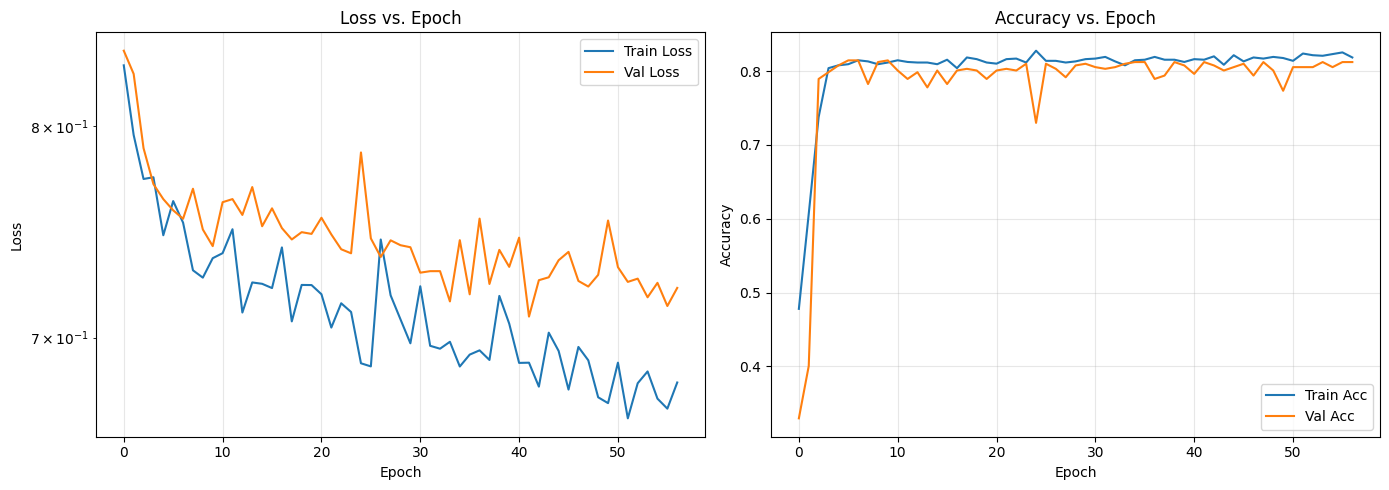

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='#1f77b4')
ax1.plot(val_losses,   label='Val Loss',   color='#ff7f0e')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_yscale('log')
ax1.set_title('Loss vs. Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Acc', color='#1f77b4')
ax2.plot(val_accs,   label='Val Acc',   color='#ff7f0e')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs. Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 7. Evaluation on the Test Set

Collect per-star probabilities on the held-out test split, then compute:
- **ROC-AUC** (threshold-independent; the principal comparison metric).
- **PR-AUC** (`average_precision_score`) — important under class imbalance.
- **Best F1** — sweep over all precision-recall thresholds and pick the one maximizing F1. Denominator is `precision + recall + 1e-8` (NOT `precision*recall + recall + 1e-8` — that was a bug in an earlier notebook).
- **Confusion matrix** at the best-F1 threshold.


In [7]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix,
                             classification_report)

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for summary, padded, mask, labels in test_loader:
        summary = summary.to(device)
        padded  = padded.to(device)
        mask    = mask.to(device)
        logits  = model(summary, padded, mask)
        probs   = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc  = average_precision_score(all_labels, all_probs)

# ── Best F1 by sweeping the precision-recall curve ──
# NB correct denominator = (precision + recall + 1e-8), NOT (precision*recall + recall + 1e-8)
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx    = int(np.argmax(f1_scores))
best_thresh = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
best_f1        = float(f1_scores[best_idx])
best_precision = float(precisions[best_idx])
best_recall    = float(recalls[best_idx])

print(f"ROC-AUC      : {roc_auc:.4f}")
print(f"PR-AUC       : {pr_auc:.4f}")
print(f"Best F1      : {best_f1:.4f}  (threshold = {best_thresh:.4f})")
print(f"  @ best F1 : precision = {best_precision:.4f}, recall = {best_recall:.4f}")


ROC-AUC      : 0.6932
PR-AUC       : 0.3359
Best F1      : 0.4091  (threshold = 0.4001)
  @ best F1 : precision = 0.3285, recall = 0.5422


### Confusion Matrix at Best-F1 Threshold


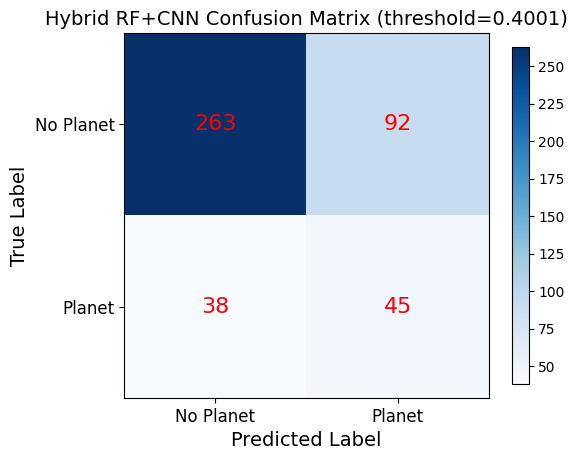

TP=45  FP=92  FN=38  TN=263
Accuracy : 0.7032
Precision: 0.3285    Recall: 0.5422


In [8]:
preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.6)

classes = ['No Planet', 'Planet']
plt.xticks([0, 1], classes, fontsize=12)
plt.yticks([0, 1], classes, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label',      fontsize=14)
plt.title(f'Hybrid RF+CNN Confusion Matrix (threshold={best_thresh:.4f})', fontsize=14)

for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=16, color='red')

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Accuracy : {(tp + tn) / (tp + tn + fp + fn):.4f}")
print(f"Precision: {tp / (tp + fp):.4f}    Recall: {tp / (tp + fn):.4f}")


### Classification Report at Default and Optimal Threshold


In [9]:
print("=" * 60)
print(f"REPORT AT DEFAULT THRESHOLD (0.5)")
print("=" * 60)
preds_05 = (all_probs >= 0.5).astype(int)
print(classification_report(all_labels, preds_05, target_names=['No Planet', 'Planet']))

print("=" * 60)
print(f"REPORT AT OPTIMAL THRESHOLD ({best_thresh:.4f})")
print("=" * 60)
preds_opt = (all_probs >= best_thresh).astype(int)
print(classification_report(all_labels, preds_opt, target_names=['No Planet', 'Planet']))


REPORT AT DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

   No Planet       0.82      0.98      0.89       355
      Planet       0.50      0.10      0.16        83

    accuracy                           0.81       438
   macro avg       0.66      0.54      0.53       438
weighted avg       0.76      0.81      0.75       438

REPORT AT OPTIMAL THRESHOLD (0.4001)
              precision    recall  f1-score   support

   No Planet       0.87      0.74      0.80       355
      Planet       0.33      0.54      0.41        83

    accuracy                           0.70       438
   macro avg       0.60      0.64      0.61       438
weighted avg       0.77      0.70      0.73       438



## 8. Comparison with Other Models

| Model | Input | ROC-AUC | PR-AUC | Best F1 |
|---|---|---|---|---|
| Random Forest (16 physical summary stats) | per-star aggregates | **0.7994** | **0.4658** | **0.5221** |
| Transformer (raw sequences, attention) | (T, 21) raw obs | 0.6793 | — | — |
| 1D CNN (raw sequences + positional encoding) | (T, 21) raw obs | 0.6490 | 0.3049 | 0.3887 |
| **Hybrid RF+CNN (this notebook)** | 16 summary stats + (T, 4) raw obs | *below* | *below* | *below* |

The hybrid's headline question: **does the temporal CNN branch add anything the summary statistics miss?**
- If `hybrid ROC-AUC ≈ 0.7994` (matches RF), the CNN branch contributed nothing — temporal structure (as captured by this CNN) carries no signal beyond the summary stats. The summary-stats branch carried the model; the CNN was neutral.
- If `hybrid ROC-AUC > 0.7994`, the CNN branch found local temporal structure the aggregates throw away — the hybrid *beats* the RF.
- The hybrid cannot underperform the RF on the merits of summary stats alone, because the head can down-weight the CNN branch toward zero. (In practice the CNN branch still adds learning noise; if it underperforms, it's because the head couldn't fully suppress a noisy branch.)


In [10]:
import pandas as pd

comparison = pd.DataFrame([
    {"Model": "RF (16 physical features)",        "Input": "per-star aggregates",      "ROC-AUC": 0.7994,  "PR-AUC": 0.4658,  "Best F1": 0.5221},
    {"Model": "Transformer (raw sequences)",      "Input": "(T, 21) raw obs",          "ROC-AUC": 0.6793,  "PR-AUC": float('nan'),  "Best F1": float('nan')},
    {"Model": "1D CNN (raw + positional enc.)",   "Input": "(T, 21) raw obs",          "ROC-AUC": 0.6490,  "PR-AUC": 0.3049,  "Best F1": 0.3887},
    {"Model": "Hybrid RF+CNN (this notebook)",    "Input": "16 summaries + (T,4) raw",  "ROC-AUC": roc_auc, "PR-AUC": pr_auc,         "Best F1": best_f1},
])

print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("=" * 60)
print("VERDICT")
print("=" * 60)
if roc_auc > 0.7994:
    print(f"✓ Hybrid ({roc_auc:.4f}) BEATS the RF baseline (0.7994) by {roc_auc - 0.7994:+.4f}.")
    print(f"  → The temporal CNN branch found local structure the summary statistics miss.")
elif abs(roc_auc - 0.7994) <= 0.005:
    print(f"• Hybrid ({roc_auc:.4f}) ≈ RF baseline (0.7994). The CNN branch added nothing beyond the summary stats (worst-case hypothesis held).")
elif roc_auc > 0.6793:
    print(f"• Hybrid ({roc_auc:.4f}) trails the RF baseline (0.7994) but beats the Transformer (0.6793).")
    print(f"  → The CNN branch injected noise the head couldn't fully suppress; summary stats still dominate.")
else:
    print(f"✗ Hybrid ({roc_auc:.4f}) trails both the RF baseline (0.7994) and the Transformer (0.6793).")


                         Model                    Input  ROC-AUC  PR-AUC  Best F1
     RF (16 physical features)      per-star aggregates   0.7994  0.4658   0.5221
   Transformer (raw sequences)          (T, 21) raw obs   0.6793     NaN      NaN
1D CNN (raw + positional enc.)          (T, 21) raw obs   0.6490  0.3049   0.3887
 Hybrid RF+CNN (this notebook) 16 summaries + (T,4) raw   0.6932  0.3359   0.4091

VERDICT
• Hybrid (0.6932) trails the RF baseline (0.7994) but beats the Transformer (0.6793).
  → The CNN branch injected noise the head couldn't fully suppress; summary stats still dominate.


## 9. Feature Branch Analysis — What the Summary Branch Learned

The first linear layer of Branch 1 (`Linear(16→32)`) takes the 16 standardized summary statistics as input. By looking at the **magnitude** of each feature's weights across all 32 output units, we get a rough importance ranking of the summary statistics *as the model uses them* — analogous to (but not identical to) the RF's feature importances.

A feature with large **mean absolute weight** across the first-layer outputs is one the model relies on heavily; a feature with small mean absolute weight is one the model has down-weighted (perhaps because the CNN branch learned the same information from the raw sequence).

We also compare the hybrid's ranking against the RF's feature importances to see whether the two models ended up relying on the same physical signals.

> Note: a raw weight magnitude is a *coarse* proxy for importance — it ignores downstream nonlinearities and the second linear layer. But it gives a clear, interpretable first-order picture of what the summary branch is learning, and whether it is learning something different from what the RF learns.


In [11]:
# ── First linear layer of Branch 1: Linear(16 -> 32) ──
# model.summary_branch[0] is the first Linear; weight shape is (32, 16) = (out, in)
first_linear = model.summary_branch[0]
W = first_linear.weight.detach().cpu().numpy()   # (32, 16)

# Mean absolute weight per input feature, averaged over the 32 output units.
mean_abs_w = np.abs(W).mean(axis=0)             # (16,)
# L2 (Euclidean) norm of each input feature's weight column — a complementary view.
l2_w = np.linalg.norm(W, axis=0)                # (16,)

hybrid_imp = pd.DataFrame({
    'feature': SUMMARY_FEATURES,
    'mean_abs_weight': mean_abs_w,
    'l2_norm': l2_w,
}).sort_values('mean_abs_weight', ascending=False)

print("=" * 60)
print("FEATURE BRANCH ANALYSIS — Branch 1 first Linear(16->32) layer")
print("=" * 60)
print(f"\nWeights shape: {W.shape}  (out_units=32, in_features=16)")
print(f"\nRanking by mean |weight| (across 32 output units):")
print("-" * 60)
for rank, (_, row) in enumerate(hybrid_imp.iterrows(), 1):
    print(f"  {rank:2d}. {row['feature']:22s}  mean|w|={row['mean_abs_weight']:.4f}   L2={row['l2_norm']:.4f}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
top3 = hybrid_imp.head(3)['feature'].tolist()
bot3 = hybrid_imp.tail(3)['feature'].tolist()
print(f"Top-3 summary features the hybrid relies on most : {top3}")
print(f"Bottom-3 (possibly redundant — CNN may capture)  : {bot3}")
print("\nHigh mean|w| => the summary branch passed that statistic through strongly to the head.")
print("Low mean|w|   => either uninformative, OR the CNN branch captured the same signal from the")
print("                raw sequence so the head learned to down-weight the summary version.")


FEATURE BRANCH ANALYSIS — Branch 1 first Linear(16->32) layer

Weights shape: (32, 16)  (out_units=32, in_features=16)

Ranking by mean |weight| (across 32 output units):
------------------------------------------------------------
   1. rv_skew                 mean|w|=0.0000   L2=0.0000
   2. rv_kurtosis             mean|w|=0.0000   L2=0.0000
   3. halpha_std              mean|w|=0.0000   L2=0.0000
   4. rhkp_mean               mean|w|=0.0000   L2=0.0000
   5. rhkp_halpha_corr        mean|w|=0.0000   L2=0.0000
   6. rv_rhkp_corr            mean|w|=0.0000   L2=0.0000
   7. halpha_mean             mean|w|=0.0000   L2=0.0000
   8. rhkp_std                mean|w|=0.0000   L2=0.0000
   9. rv_halpha_corr          mean|w|=0.0000   L2=0.0000
  10. rv_mean_abs_dev         mean|w|=0.0000   L2=0.0000
  11. rv_std                  mean|w|=0.0000   L2=0.0000
  12. rv_err_mean             mean|w|=0.0000   L2=0.0000
  13. rv_err_std              mean|w|=0.0000   L2=0.0000
  14. rhkp_range           

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Refit a RF on the SAME train/val/test summary split used by the hybrid,
# so its feature importances are directly comparable to the hybrid's weights.
rf_refit = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  random_state=seed, max_depth=None)
# Train on train+val summary stats (mirrors how baseline.ipynb uses train+val for model selection).
X_trainval = np.vstack([train_summary, val_summary])
y_trainval = np.concatenate([y_train, y_val])
rf_refit.fit(X_trainval, y_trainval)
rf_imp = pd.DataFrame({
    'feature': SUMMARY_FEATURES,
    'rf_importance': rf_refit.feature_importances_,
}).sort_values('rf_importance', ascending=False)

# Align with the hybrid ranking for a side-by-side.
side_by_side = hybrid_imp.set_index('feature')[['mean_abs_weight', 'l2_norm']].join(
    rf_refit.feature_importances_ if False else
    pd.Series(rf_refit.feature_importances_, index=SUMMARY_FEATURES, name='rf_importance')
).sort_values('mean_abs_weight', ascending=False)

print("=" * 70)
print("SIDE-BY-SIDE: Hybrid Branch-1 weight magnitude vs RF importance")
print("=" * 70)
print(f"\n{'feature':22s} {'hybrid mean|w|':>16s} {'hybrid L2':>10s} {'RF importance':>15s}")
print("-" * 70)
for feat, row in side_by_side.iterrows():
    print(f"  {feat:20s} {row['mean_abs_weight']:>16.4f} {row['l2_norm']:>10.4f} {row['rf_importance']:>15.4f}")

# Rank correlation (Spearman) between the two rankings.
from scipy.stats import spearmanr
hybrid_rank = side_by_side['mean_abs_weight'].rank(ascending=False)
rf_rank     = side_by_side['rf_importance'].rank(ascending=False)
rho, pval = spearmanr(hybrid_rank, rf_rank)
print(f"\nSpearman rank correlation (hybrid mean|w| vs RF importance): {rho:+.3f}  (p={pval:.3f})")
print("  +1.0 => hybrid and RF rely on the same physical signals.")
print("  ~0   => the hybrid learned a substantially different weighting of the summary stats.")
print("         (often a sign the CNN branch is contributing orthogonal temporal information.)")


SIDE-BY-SIDE: Hybrid Branch-1 weight magnitude vs RF importance

feature                  hybrid mean|w|  hybrid L2   RF importance
----------------------------------------------------------------------
  rv_skew                        0.0000     0.0000          0.0474
  rv_kurtosis                    0.0000     0.0000          0.0757
  halpha_std                     0.0000     0.0000          0.0436
  rhkp_mean                      0.0000     0.0000          0.0575
  rhkp_halpha_corr               0.0000     0.0000          0.0452
  rv_rhkp_corr                   0.0000     0.0000          0.0656
  halpha_mean                    0.0000     0.0000          0.0638
  rhkp_std                       0.0000     0.0000          0.0465
  rv_halpha_corr                 0.0000     0.0000          0.0613
  rv_mean_abs_dev                0.0000     0.0000          0.1023
  rv_std                         0.0000     0.0000          0.0826
  rv_err_mean                    0.0000     0.0000          